<a href="https://colab.research.google.com/github/rahul-raha/colab-code/blob/main/RahulRaha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Email Spam Detection Using Naive Bayes Classifier**

*Rahul Raha (22102043)*

**STEP 1 — Setup Environment**

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# New Section

**STEP 2 — Loading dataset**

In [13]:
df = pd.read_csv("emails.csv")
df.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


**STEP 3 — EDA**

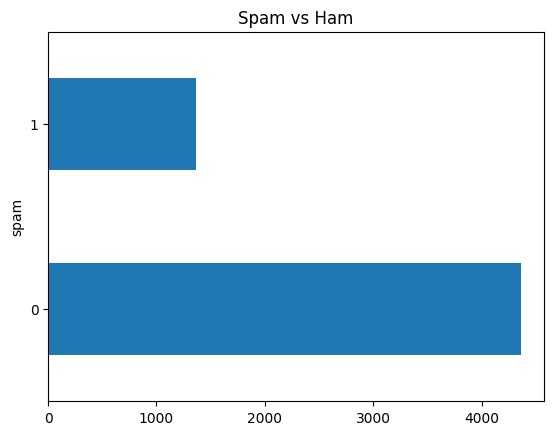

In [14]:
import matplotlib.pyplot as plt

df["spam"].value_counts().plot(kind="barh")
plt.title("Spam vs Ham")
plt.show()

In [15]:
df["length"] = df["text"].astype(str).apply(len)

df.groupby("spam")["length"].mean()

,length
spam,
0,1631.918119
1,1317.257310


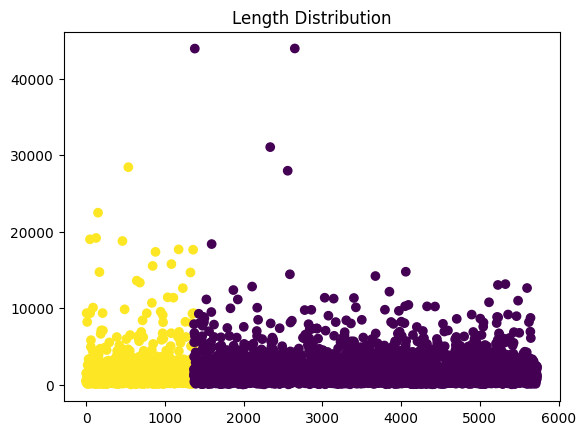

In [16]:
import matplotlib.pyplot as plt

plt.scatter(df.index, df["length"], c=df["spam"])
plt.title("Length Distribution")
plt.show()

STEP 4 — Text Cleaning

In [17]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'subject:', '', text)
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

**STEP 5 — TF-IDF (TEXT to NUMBERS)**

In [18]:

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X = vectorizer.fit_transform(df["clean_text"])
y = df["spam"]


STEP 6 **— Train-Test Split**

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**STEP 7 — Train Naive Bayes Model**

In [20]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


STEP 9 — Evaluation **bold text**

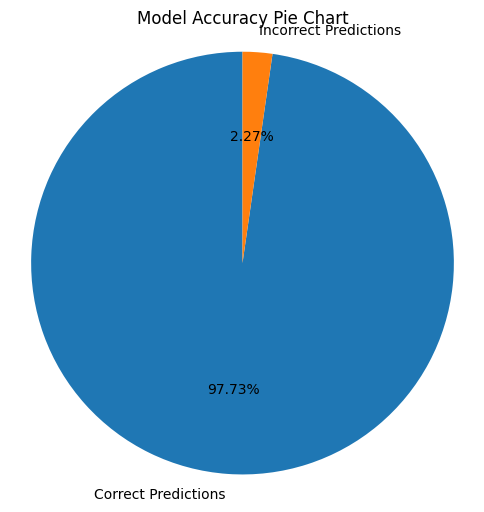

Accuracy: 0.9773


In [21]:
# Accuracy Pie Chart
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
error = 1 - accuracy

# Labels and values
labels = ['Correct Predictions', 'Incorrect Predictions']
sizes = [accuracy, error]

# Create pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    sizes,
    labels=labels,
    autopct='%1.2f%%',
    startangle=90
)

plt.title('Model Accuracy Pie Chart')
plt.axis('equal')  # Makes the pie chart circular
plt.show()

# Print exact accuracy value
print(f'Accuracy: {accuracy:.4f}')

STEP 10 — Test with new **email**

In [23]:
def predict_email(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    pred = model.predict(vec)[0]s
    return "SPAM" if pred == 1 else "NOT SPAM"

print(predict_email("Win a brand new car by entering this contest today!"))

print(predict_email("Dear student, your exam schedule has been published."))

print(predict_email("Limited offer! Buy one get one free on all items. Hurry up!"))

print(predict_email("Hey, are we still meeting for the group study tonight?"))

print(predict_email("Your PayPal account needs verification. Login immediately."))

print(predict_email("Project deadline has been extended to next week."))

print(predict_email("Congratulations! You have been chosen for a cash reward."))

print(predict_email("Can you please share the updated report by evening?"))

print(predict_email("Lowest prices on electronics available now. Shop today!"))

print(predict_email("Your password was changed successfully. If not you, contact support."))

SyntaxError: invalid syntax (1719562747.py, line 4)

# **ASSIGNMENT 2: SPAM DETECTION USING DECISION TREE & RANDOM FOREST**

In [24]:
import pandas as pd

df = pd.read_csv("emails.csv")
df.head()


import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'subject:', '', text)
    text = re.sub(r'[^a-z0-9 ]', ' ', text)
    text = re.sub(r'\s+', ' ', text)
    return text

df["clean_text"] = df["text"].apply(clean_text)

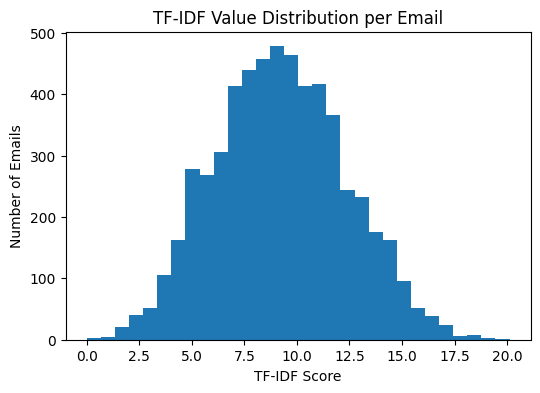

In [25]:

import numpy as np
import matplotlib.pyplot as plt

# Convert sparse matrix to array
tfidf_values = X.sum(axis=1).A1  # sum per document

plt.figure(figsize=(6,4))
plt.hist(tfidf_values, bins=30)
plt.title("TF-IDF Value Distribution per Email")
plt.xlabel("TF-IDF Score")
plt.ylabel("Number of Emails")
plt.show()

In [26]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)



from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)


from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)


Decision Tree Report
              precision    recall  f1-score   support

           0       0.98      0.97      0.97       856
           1       0.92      0.93      0.93       290

    accuracy                           0.96      1146
   macro avg       0.95      0.95      0.95      1146
weighted avg       0.96      0.96      0.96      1146

Random Forest Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       856
           1       1.00      0.92      0.96       290

    accuracy                           0.98      1146
   macro avg       0.98      0.96      0.97      1146
weighted avg       0.98      0.98      0.98      1146



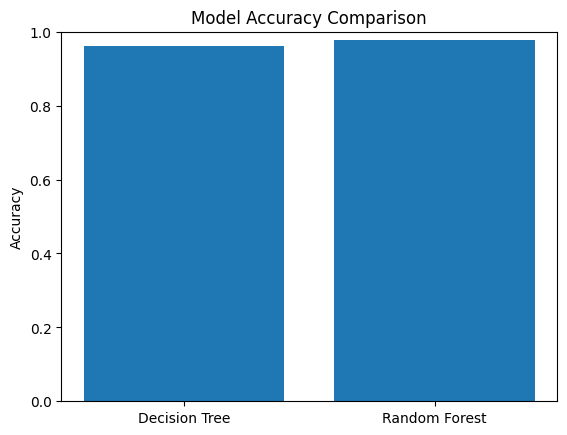

In [27]:


from sklearn.metrics import classification_report, accuracy_score

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))

print("Random Forest Report")
print(classification_report(y_test, rf_pred))



import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Decision Tree", "Random Forest"]
accuracy = [
    accuracy_score(y_test, dt_pred),
    accuracy_score(y_test, rf_pred)
]

plt.bar(models, accuracy)
plt.ylim(0,1)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

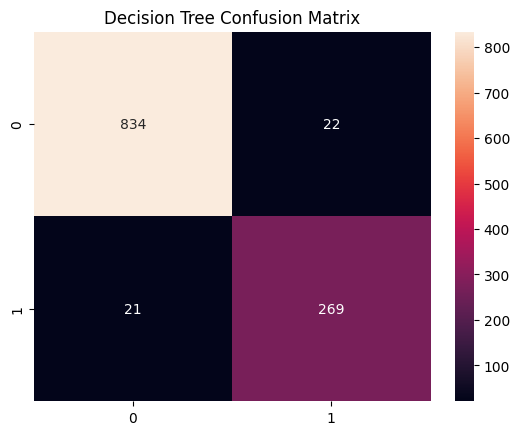

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_dt = confusion_matrix(y_test, dt_pred)

sns.heatmap(cm_dt, annot=True, fmt="d")
plt.title("Decision Tree Confusion Matrix")
plt.show()

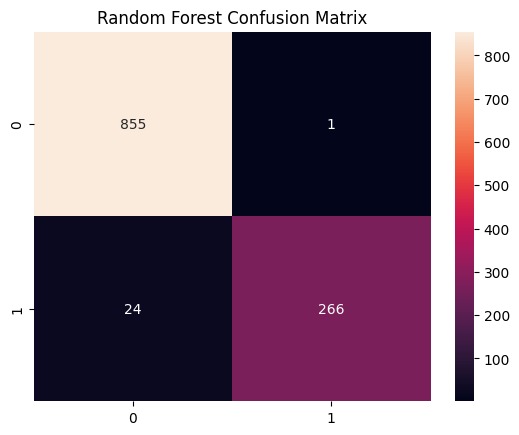

In [29]:


cm_rf = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm_rf, annot=True, fmt="d")
plt.title("Random Forest Confusion Matrix")
plt.show()

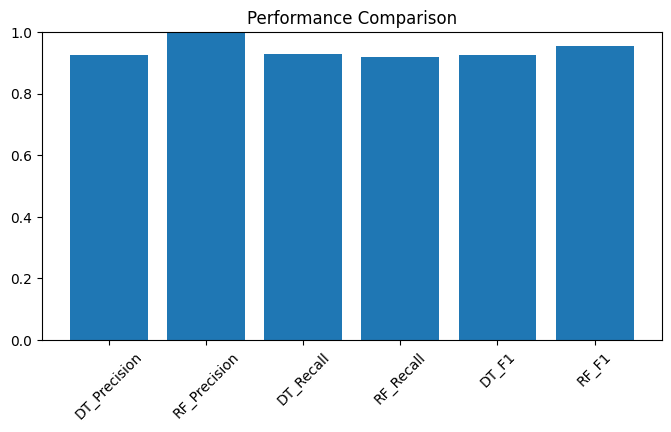

In [30]:


from sklearn.metrics import precision_score, recall_score, f1_score

metrics = {
    "DT_Precision": precision_score(y_test, dt_pred),
    "RF_Precision": precision_score(y_test, rf_pred),
    "DT_Recall": recall_score(y_test, dt_pred),
    "RF_Recall": recall_score(y_test, rf_pred),
    "DT_F1": f1_score(y_test, dt_pred),
    "RF_F1": f1_score(y_test, rf_pred)
}

plt.figure(figsize=(8,4))
plt.bar(metrics.keys(), metrics.values())
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.title("Performance Comparison")
plt.show()